In [70]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
BASE_DIR = Path().resolve().parent

DATA_PATH = BASE_DIR / "ukraine-attacks-analysis" / "data" / "raw" / "missile_attacks_daily.csv"

print(DATA_PATH)
print(DATA_PATH.exists())

df = pd.read_csv(DATA_PATH)
df.head()

/Users/vitalii/Documents/ukraine-attacks-analysis/data/raw/missile_attacks_daily.csv
True


,time_start,time_end,model,launch_place,target,target_main,launched,destroyed,not_reach_goal,still_attacking,...,num_hit_location,num_fall_fragment_location,carrier,turbojet,turbojet_destroyed,affected region,destroyed_details,launched_details,launch_place_details,source
0,2026-04-18 17:30,2026-04-19 08:00,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,236.0,203.0,0.0,1.0,...,18.0,8.0,NaN,NaN,NaN,NaN,"{'south': 23, 'east': NaN, 'north': NaN}",NaN,NaN,kpszsu/posts/pfbid0MeNK3NXQXEE3UZmCEd9ACbScZTX...
1,2026-04-17 18:00,2026-04-18 08:30,Shahed-136/131,"Primorsko-Akhtarsk and Chauda, Crimea and Kurs...",Ukraine,NaN,219.0,190.0,0.0,1.0,...,17.0,9.0,NaN,NaN,NaN,NaN,"{'south': 56, 'east': NaN, 'north': NaN}",NaN,NaN,kpszsu/posts/pfbid02SbNVam4xqrQuM1pWKBGqKsMprJ...
2,2026-04-18,2026-04-18,Unknown UAV,NaN,south,NaN,62.0,62.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid02QHv7o6nNNq7wsjui4ixPYDG...
3,2026-04-16 18:00,2026-04-17 08:00,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,172.0,147.0,0.0,5.0,...,8.0,4.0,NaN,NaN,NaN,NaN,"{'south': 86, 'east': NaN, 'north': NaN}",NaN,NaN,kpszsu/posts/pfbid0fWmfYz3KEHzAskn2FhyBgruZ2wR...
4,2026-04-16 18:00,2026-04-17 08:00,Iskander-M,Crimea,Ukraine,NaN,1.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid0fWmfYz3KEHzAskn2FhyBgruZ2wR...


In [72]:
# Create attack type classification based on model and is_shahed columns

def classify_attack(row):
    model = str(row['model']).lower()
    
    if 'shahed' in model or row.get('is_shahed', 0) == 1:
        return 'drone'
    elif any(x in model for x in ['iskander', 'kalibr', 'kh-', 'x-', 'kinzhal']):
        return 'missile'
    elif 'uav' in model:
        return 'drone'
    else:
        return 'other'

df['attack_type'] = df.apply(classify_attack, axis=1)

In [73]:
# Clean columns

df['date'] = pd.to_datetime(df['time_start'], errors='coerce')
df['launched'] = pd.to_numeric(df['launched'], errors='coerce')

df = df.dropna(subset=['date', 'attack_type'])

In [74]:
# Aggregate to daily level

daily = (
    df.groupby([df['date'].dt.date, 'attack_type'])['launched']
    .sum()
    .reset_index()
)

In [75]:
# Create pivot table for plotting

daily_pivot = daily.pivot(
    index='date',
    columns='attack_type',
    values='launched'
).fillna(0)

In [76]:
# Convert index to datetime

daily_pivot.index = pd.to_datetime(daily_pivot.index)

In [77]:
# Monthly aggregation

monthly = daily_pivot.resample('ME').sum()

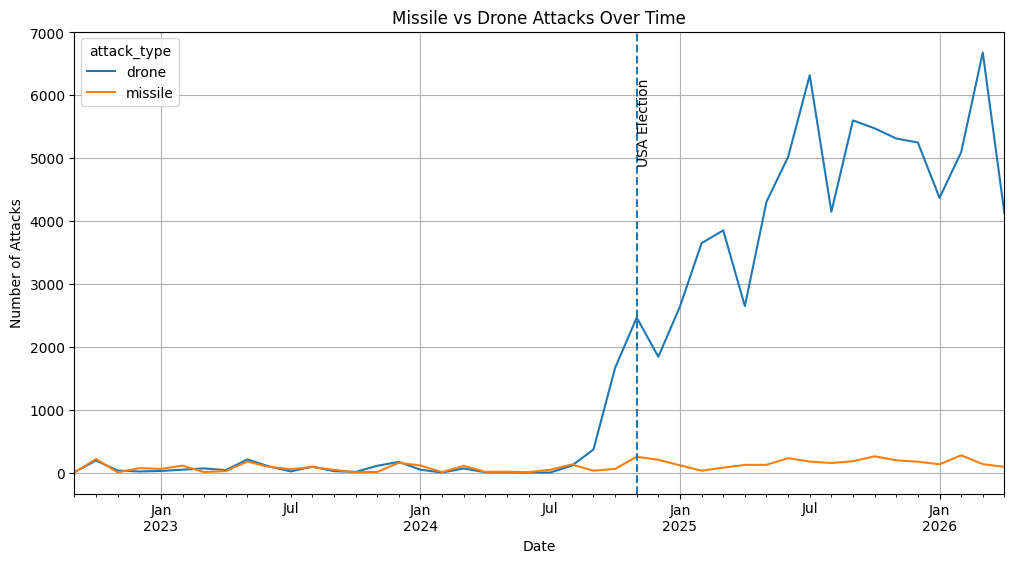

In [83]:
monthly[['drone', 'missile']].plot(figsize=(12, 6))

plt.title('Missile vs Drone Attacks Over Time')
plt.ylabel('Number of Attacks')
plt.xlabel('Date')
plt.grid()
plt.axvline(pd.to_datetime("2024-11-01"), linestyle='--')
plt.text(pd.to_datetime("2024-11-01"), plt.ylim()[1]*0.8, 'USA Election ', rotation=90, verticalalignment='center')


plt.show()

In [ ]:
monthly['total'] = monthly.sum(axis=1)

monthly['drone_share'] = monthly['drone'] / monthly['total']
monthly['missile_share'] = monthly['missile'] / monthly['total']

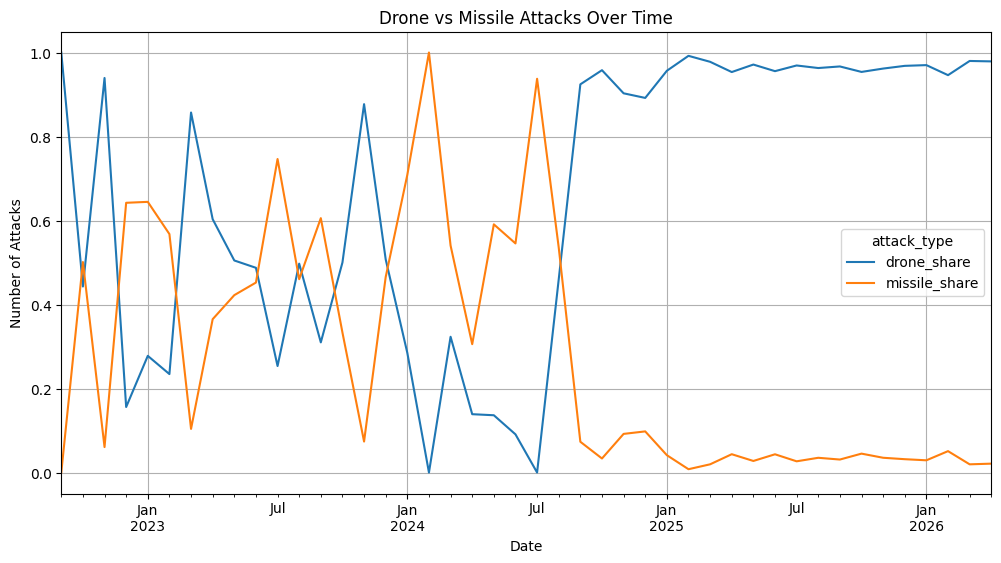

In [ ]:
monthly[['drone_share', 'missile_share']].plot(figsize=(12, 6))

plt.title('Drone vs Missile Attacks Over Time')
plt.ylabel('Number of Attacks')
plt.xlabel('Date')
plt.grid()

plt.show()

In [ ]:
# Find top attack days

top_days = daily_pivot.copy()
top_days['total'] = top_days.sum(axis=1)
top_days = top_days.sort_values('total', ascending=False)
top_days.head(10)

attack_type,drone,missile,other,total
date,,,,
2025-09-06,810.0,13.0,0.0,823.0
2025-07-08,782.0,13.0,5.0,800.0
2026-03-24,703.0,18.0,0.0,721.0
2026-04-15,659.0,44.0,0.0,703.0
2025-12-05,653.0,48.0,0.0,701.0
2025-10-29,653.0,0.0,0.0,653.0
2025-12-22,635.0,0.0,0.0,635.0
2025-11-28,596.0,36.0,0.0,632.0
2025-08-20,574.0,35.0,1.0,610.0


In [ ]:
# Seasinality analysis

monthly['month'] = monthly.index.month

seasonality = monthly.groupby('month')[['drone', 'missile']].mean()

seasonality

attack_type,drone,missile
month,,
1,1769.500000,103.750000
2,2196.250000,104.500000
3,2664.500000,81.250000
4,1703.500000,61.000000
5,1505.333333,103.000000
6,1705.333333,108.000000
7,2111.666667,90.666667
8,1449.666667,121.666667
9,1498.500000,62.750000


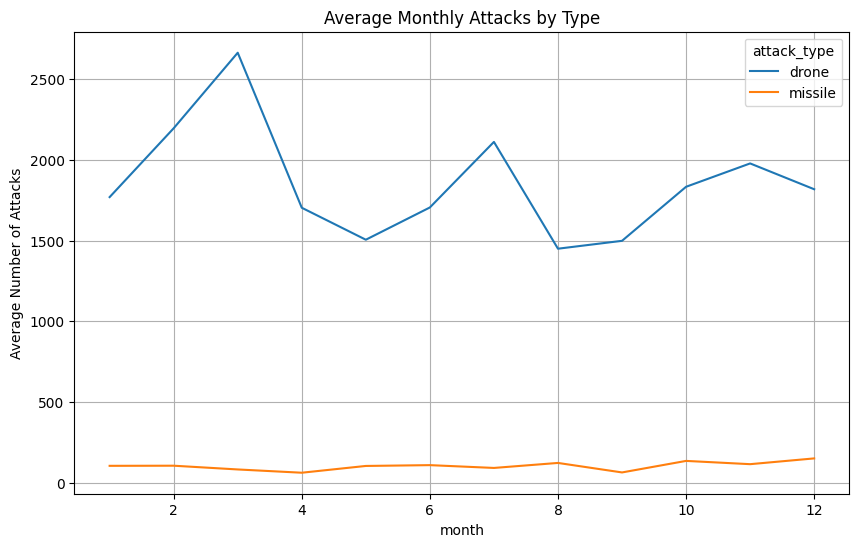

In [ ]:
seasonality.plot(figsize=(10, 6))

plt.title('Average Monthly Attacks by Type')
plt.ylabel('Average Number of Attacks')
plt.grid()

plt.show()

In [ ]:
# Year over year analysis

monthly['year'] = monthly.index.year
monthly['mounth'] = monthly.index.month

seasonality_year = (
    monthly.groupby(['year', 'month'])[['drone', 'missile']]
    .mean()
    .reset_index()
)

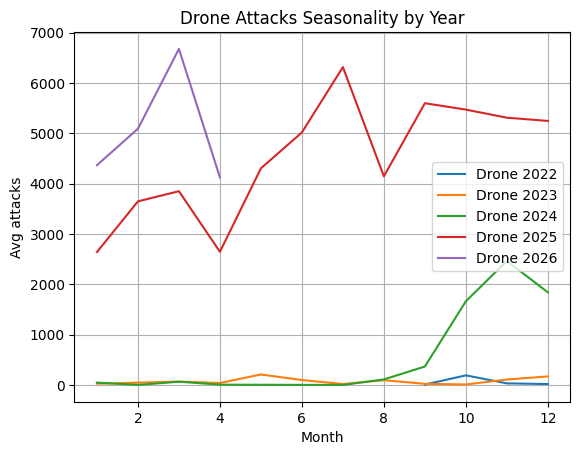

In [ ]:
import matplotlib.pyplot as plt

for year in seasonality_year['year'].unique():
    subset = seasonality_year[seasonality_year['year'] == year]
    
    plt.plot(subset['month'], subset['drone'], label=f"Drone {year}")

plt.legend()
plt.title("Drone Attacks Seasonality by Year")
plt.xlabel("Month")
plt.ylabel("Avg attacks")
plt.grid()
plt.show()

In [ ]:
# Updaing classification for cruise and ballistic missiles

def classify_attack_advanced(row):
    model = str(row['model']).lower()
    
    if 'shahed' in model or row.get('is_shahed', 0) == 1:
        return 'drone'
    elif any(x in model for x in ['iskander', 'kinzhal']):
        return 'ballistic_missile'
    elif any(x in model for x in ['kalibr', 'kh-', 'x-']):
        return 'cruise_missile'
    elif 'uav' in model:
        return 'drone'
    else:
        return 'other'

In [ ]:
# Updating year by year analysis

monthly['year'] = monthly.index.year
monthly['mounth'] = monthly.index.month

# First, apply the advanced classification to df
df['attack_type'] = df.apply(classify_attack_advanced, axis=1)

# Reaggregate daily data with new classifications
daily = (
    df.groupby([df['date'].dt.date, 'attack_type'])['launched']
    .sum()
    .reset_index()
)

# Create new pivot table
daily_pivot = daily.pivot(
    index='date',
    columns='attack_type',
    values='launched'
).fillna(0)

# Convert index to datetime
daily_pivot.index = pd.to_datetime(daily_pivot.index)

# Reaggregate to monthly
monthly = daily_pivot.resample('ME').sum()

# Now perform the year by year analysis
monthly['year'] = monthly.index.year
monthly['month'] = monthly.index.month

seasonality_year = (
    monthly.groupby(['year', 'month'])[['drone', 'ballistic_missile', 'cruise_missile']]
    .mean()
    .reset_index()
)

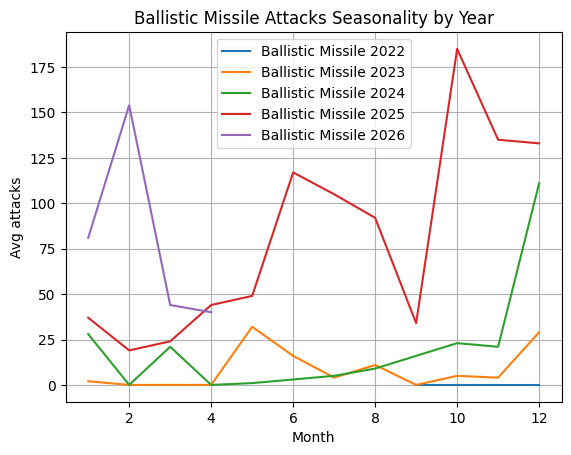

In [ ]:
for year in seasonality_year['year'].unique():
    subset = seasonality_year[seasonality_year['year'] == year]
    
    plt.plot(subset['month'], subset['ballistic_missile'], label=f"Ballistic Missile {year}")

plt.legend()
plt.title("Ballistic Missile Attacks Seasonality by Year")
plt.xlabel("Month")
plt.ylabel("Avg attacks")
plt.grid()
plt.show()

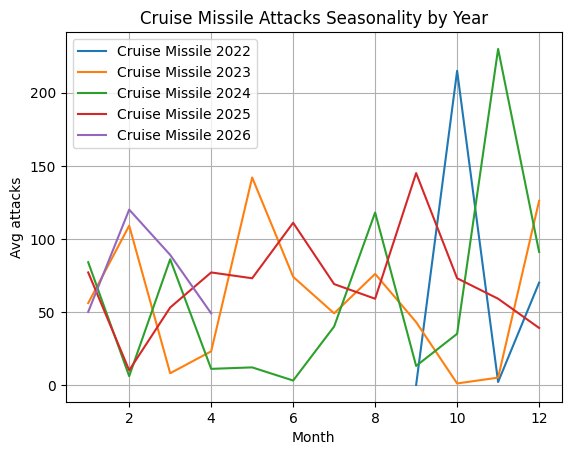

In [ ]:
for year in seasonality_year['year'].unique():
    subset = seasonality_year[seasonality_year['year'] == year]
    
    plt.plot(subset['month'], subset['cruise_missile'], label=f"Cruise Missile {year}")

plt.legend()
plt.title("Cruise Missile Attacks Seasonality by Year")
plt.xlabel("Month")
plt.ylabel("Avg attacks")
plt.grid()
plt.show()